<a href="https://colab.research.google.com/github/fanisam/Praktikum_AI/blob/main/Studi_Kasus_Linear_Berganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Skenario**:

 Mengestimasi performa komputasi dalam pengembangan aplikasi. Kita memprediksi total Baris Kode (Ribuan) yang dihasilkan berdasarkan Jam Ngoding dan Jumlah Form GUI (misal: AWT/Swing) yang diimplementasikan.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt

In [8]:
data_app = {
    'jam_ngoding': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    'jumlah_form_gui': [2, 3, 3, 4, 5, 5, 6, 7, 7, 8],
    'baris_kode_ribuan': [1.2, 1.8, 2.1, 2.7, 3.5, 3.8, 4.5, 5.2, 5.5, 6.1]
}
df_app = pd.DataFrame
(data_app)

{'jam_ngoding': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
 'jumlah_form_gui': [2, 3, 3, 4, 5, 5, 6, 7, 7, 8],
 'baris_kode_ribuan': [1.2, 1.8, 2.1, 2.7, 3.5, 3.8, 4.5, 5.2, 5.5, 6.1]}

In [5]:
X = df_app[['jam_ngoding', 'jumlah_form_gui']]
y = df_app['baris_kode_ribuan']

In [10]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model_berganda = LinearRegression()
model_berganda.fit(X_train_b, y_train_b)

LinearRegression()

In [12]:
print("Intercept (a):", model_berganda.intercept_)
print("Koefisien (Jam, Form GUI):", model_berganda.coef_)

Intercept (a): -0.25000000000000044
Koefisien (Jam, Form GUI): [0.05166667 0.44166667]


In [18]:
import numpy as np
y_pred_b = model_berganda.predict(X_test_b)
print("\n=== Evaluasi Model Berganda ===")
print("Data Asli:", y_test_b.values)
print("Data Prediksi:", y_pred_b)
print("MSE:", metrics.mean_squared_error(y_test_b, y_pred_b))
print("MAE:", metrics.mean_absolute_error(y_test_b, y_pred_b))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test_b, y_pred_b)))


=== Evaluasi Model Berganda ===
Data Asli: [5.5 1.8]
Data Prediksi: [5.425 1.85 ]
MSE: 0.004062499999999926
MAE: 0.062499999999999445
RMSE: 0.06373774391990923


In [16]:
pred_app_baru = model_berganda.predict([[60, 10]])
print(f"\nPrediksi baris kode untuk 60 jam dan 10 Form GUI: {pred_app_baru[0]:.2f} Ribu Baris")


Prediksi baris kode untuk 60 jam dan 10 Form GUI: 7.27 Ribu Baris


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


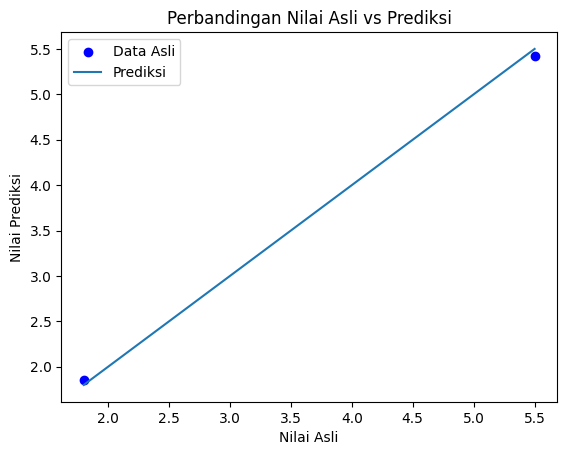

In [20]:
plt.scatter(y_test_b, y_pred_b, color ='blue', label='Data Asli')
plt.plot(y_test_b, y_test_b, label='Prediksi')
plt.xlabel("Nilai Asli")
plt.ylabel("Nilai Prediksi")
plt.title("Perbandingan Nilai Asli vs Prediksi")
plt.legend()
plt.show()

**Analisis:**


Karena melibatkan perancangan interface, penambahan jumlah_form_gui berkontribusi besar terhadap pembengkakan baris kode. Model ini membuktikan seberapa besar bobot (koefisien) layouting form secara terprogram dibandingkan sekadar logika bisnis biasa yang direpresentasikan oleh jam_ngoding.